In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [11]:
#load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [12]:
print(train.shape)
print(test.shape)

(1821, 5)
(1821, 1)


In [13]:
# label column
train['label'] = train[['healthy', 'multiple_diseases', 'scab', 'rust']].idxmax(axis=1)

In [14]:
# seting image_path into csv file in image column
train['images'] = train['image_id'].apply(lambda x : f"images/{x}.jpg")
test['images'] = test['image_id'].apply(lambda x : f"images/{x}.jpg")

In [15]:
print(train)

        image_id  healthy  multiple_diseases  rust  scab              label  \
0        Train_0        0                  0     0     1               scab   
1        Train_1        0                  1     0     0  multiple_diseases   
2        Train_2        1                  0     0     0            healthy   
3        Train_3        0                  0     1     0               rust   
4        Train_4        1                  0     0     0            healthy   
...          ...      ...                ...   ...   ...                ...   
1816  Train_1816        0                  0     0     1               scab   
1817  Train_1817        1                  0     0     0            healthy   
1818  Train_1818        1                  0     0     0            healthy   
1819  Train_1819        0                  0     1     0               rust   
1820  Train_1820        0                  0     0     1               scab   

                     images  
0        images/Train

In [16]:
print(test)

       image_id                images
0        Test_0     images/Test_0.jpg
1        Test_1     images/Test_1.jpg
2        Test_2     images/Test_2.jpg
3        Test_3     images/Test_3.jpg
4        Test_4     images/Test_4.jpg
...         ...                   ...
1816  Test_1816  images/Test_1816.jpg
1817  Test_1817  images/Test_1817.jpg
1818  Test_1818  images/Test_1818.jpg
1819  Test_1819  images/Test_1819.jpg
1820  Test_1820  images/Test_1820.jpg

[1821 rows x 2 columns]


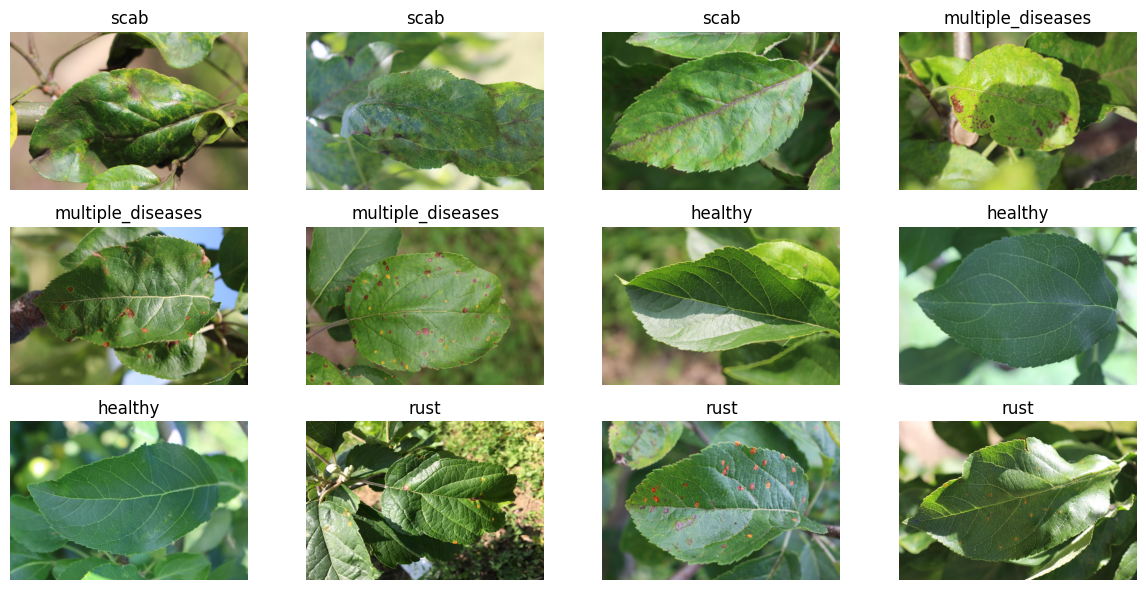

In [22]:
# visualizing images with label
classes = train['label'].unique()

plt.figure(figsize=(12,6))
i=1
for label in classes:
    sample = train[train['label']==label].sample(3)
    for row in sample.itertuples():
        img = mpimg.imread(row.images)
        plt.subplot(3, 4, i)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
        i+=1

plt.tight_layout()
plt.show()


In [23]:
#preprocessing
import cv2
import numpy as np
import random
from tqdm import tqdm

def preprocess_images(image_paths, size=(128, 128), augment=False):
    processed_images = []
    for path in tqdm(image_paths):
        img = cv2.imread(path)
        if img is not None:
            img = cv2.resize(img, size)   # image resize
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Normalization
            img = img / 255.0

            # augmentation
            if augment:
                if random.random() > 0.5:
                    img = cv2.flip(img, 1) 
                if random.random() > 0.5:
                    angle = random.randint(-15, 15)
                    M = cv2.getRotationMatrix2D((size[0]//2, size[1]//2), angle, 1)
                    img = cv2.warpAffine(img, M, size)

            processed_images.append(img)
    return processed_images

train_img = preprocess_images(train['images'].values, augment=True)
test_img = preprocess_images(test['images'].values, augment=True)


100%|██████████| 1821/1821 [00:38<00:00, 46.87it/s]


In [ ]:
from skimage.feature import hog, local_binary_pattern
def extract_features(images):
    feature_list = []
    for gray in tqdm(images):
        if len(gray.shape) == 3:
            gray = cv2.cvtColor(gray, cv2.COLOR_BGR2GRAY)
        
        # grascale to rgb for color histogram
        rgb = cv2.cvtColor((gray * 255).astype('uint8'), cv2.COLOR_GRAY2BGR)

        # HOG features
        hog_feat = hog(gray, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=False)

        # Color histogram 
        hist = cv2.calcHist([rgb], [0, 1, 2], None, [8, 8, 8], [0,256, 0,256, 0,256])
        color_feat = cv2.normalize(hist, hist).flatten()

        # Texture features 
        lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
        hist_lbp, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
        texture_feat = hist_lbp.astype("float")
        texture_feat /= (texture_feat.sum() + 1e-6)

        # Edge features
        edges = cv2.Canny((gray * 255).astype('uint8'), 100, 200)
        edge_feat = edges.flatten()[:1000]  

        combined = np.concatenate([hog_feat, color_feat, texture_feat, edge_feat])
        feature_list.append(combined)
    
    return feature_list

x_train = extract_features(train_img)
x_test = extract_features(test_img)


  0%|          | 0/1821 [00:00<?, ?it/s]c:\Users\admin\Desktop\CSI_Project\.venv\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 1821/1821 [00:21<00:00, 86.65it/s]


In [25]:
from sklearn.preprocessing import LabelEncoder
le  = LabelEncoder()
y_train = le.fit_transform(train['label'])
print(le.classes_)

['healthy' 'multiple_diseases' 'rust' 'scab']


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [27]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy: ",accuracy_score(Y_test,y_pred))
print("Classfication_report:\n ",classification_report(Y_test,y_pred,target_names=le.classes_))

Accuracy:  0.4767123287671233
Classfication_report:
                     precision    recall  f1-score   support

          healthy       0.47      0.37      0.42       100
multiple_diseases       0.00      0.00      0.00        18
             rust       0.44      0.54      0.49       120
             scab       0.52      0.57      0.54       127

         accuracy                           0.48       365
        macro avg       0.36      0.37      0.36       365
     weighted avg       0.45      0.48      0.46       365



c:\Users\admin\Desktop\CSI_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\Desktop\CSI_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\Desktop\CSI_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [65]:
import joblib

joblib.dump(model, "plant_phatology_model.pkl")

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']